# Classification

In [67]:
from ExtractData import *
from sklearn import model_selection
import sklearn.linear_model as lm
from dtuimldmtools import rlr_validate, mcnemar
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [68]:
# df_encoded = pd.get_dummies(df, columns=["Country"], drop_first=False, dtype=int)
df_encoded = df.drop(["Car Make"], axis=1)
# print(df_encoded.describe(include="all"))

# Extract target and features
y = df_encoded["Country"].to_numpy()
X = df_encoded.drop(["Country"], axis=1).to_numpy()
X = np.nan_to_num(X).astype(float)
X = np.hstack([np.ones((X.shape[0], 1)), X])
attributeNames = [
    "Offset",
    "Year",
    "Engine Size (L)",
    "Horsepower",
    "Torque (lb-ft)",
    "0-60 MPH Time (seconds)",
    "Price (in USD)",
]

N, M = X.shape
C = len(Countries)
Folds = 10

# Cross validation
Outer_CV = model_selection.KFold(n_splits=Folds, shuffle=False)  # was False
inner_CV = 5

# Values of lambda
lambdas = np.power(10.0, np.arange(-4, 9, 0.05))


# Initialize variables
y_pred_MLR = np.zeros((len(y)))

# Initialize variables
# T = len(lambdas)
Error_train = np.empty((Folds, 1))
Error_test = np.empty((Folds, 1))
Error_train_rlr = np.empty((Folds, 1))
Error_test_rlr = np.empty((Folds, 1))
Error_train_nofeatures = np.empty((Folds, 1))
Error_test_nofeatures = np.empty((Folds, 1))
w_rlr = np.empty((M, Folds))
mu = np.empty((Folds, M - 1))
sigma = np.empty((Folds, M - 1))
w_noreg = np.empty((M, Folds))

k = 0

Lambda in outer fold 1 is 251.18864315094487
Error rate in outer fold 1 is 0.6831683168316832

Weights in last fold:
Lambda in outer fold 2 is 0.0019952623149688585
Error rate in outer fold 2 is 0.32673267326732675

Weights in last fold:
         Offset            -0.0
           Year             0.0
Engine Size (L)            -0.0
     Horsepower            -0.0
 Torque (lb-ft)             0.0
0-60 MPH Time (seconds)             0.0
 Price (in USD)             0.0


Lambda in outer fold 3 is 0.01995262314968842
Error rate in outer fold 3 is 0.45544554455445546

Weights in last fold:
Lambda in outer fold 4 is 251.18864315094487
Error rate in outer fold 4 is 0.7128712871287128

Weights in last fold:
Lambda in outer fold 5 is 1778.2794100388173
Error rate in outer fold 5 is 0.7326732673267327

Weights in last fold:
Lambda in outer fold 6 is 0.022387211385682965
Error rate in outer fold 6 is 0.504950495049505

Weights in last fold:
Lambda in outer fold 7 is 1258.925411794094
Error rate in

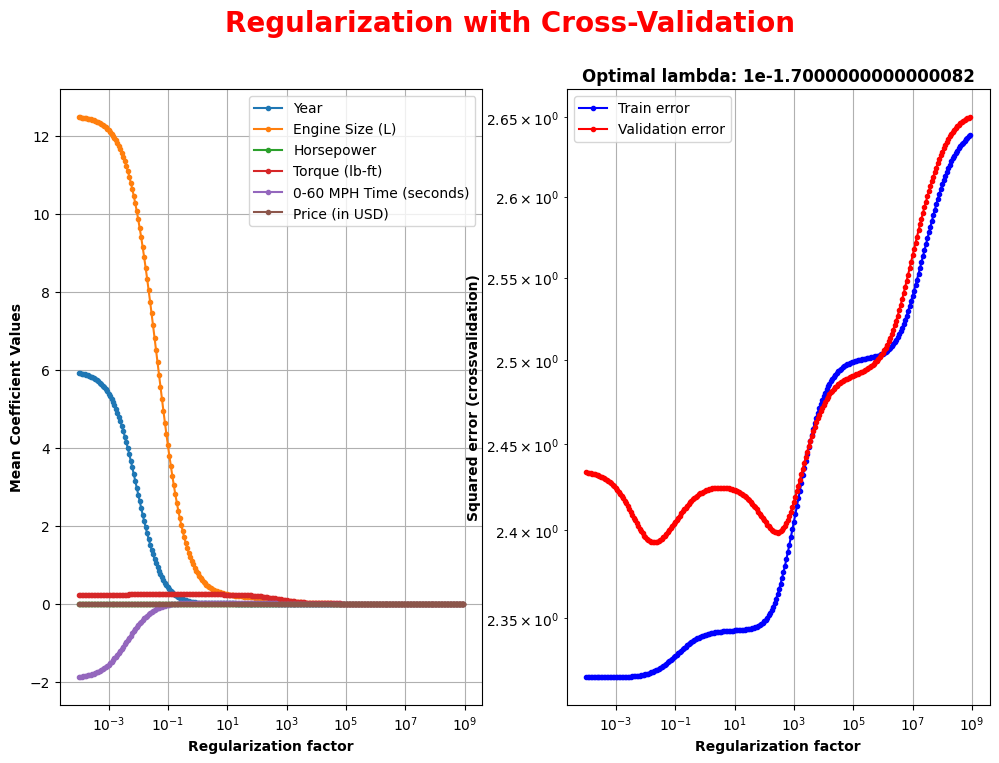

Linear regression without feature selection:
- Training error: 4.585414278447494
- Test error:     4.855158415841585
- R^2 train:     -0.44071621413944895
- R^2 test:     -0.5527257119112909

Regularized linear regression:
- Training error: 2.3782899088281937
- Test error:     2.6048867258897634
- R^2 train:     0.2527521777741929
- R^2 test:     0.16693251805989567

Weights in last fold:
         Offset            2.04
           Year            0.02
Engine Size (L)            0.28
     Horsepower           -0.01
 Torque (lb-ft)             0.7
0-60 MPH Time (seconds)            0.01
 Price (in USD)            0.19


In [69]:
for train_index, test_index in Outer_CV.split(X, y):

    # extract training and test set for current CV fold
    X_train = X[train_index]
    y_train = y[train_index]
    X_test = X[test_index]
    y_test = y[test_index]
    ##NOTE rlr_validate HAS BEEN CHANGED FROM THE GIVEN LIBRARY, now it takes a bool as input to block shuffling
    (
        opt_val_err,
        opt_lambda,
        mean_w_vs_lambda,
        train_err_vs_lambda,
        test_err_vs_lambda,
    ) = rlr_validate(X_train, y_train, lambdas, inner_CV)
    print("Lambda in outer fold {0} is {1}".format(k + 1, opt_lambda))  ##print lambda
    # Standardize outer fold based on training set, and save the mean and standard
    # deviations since they're part of the model (they would be needed for
    # making new predictions) - for brevity we won't always store these in the scripts
    mu[k, :] = np.mean(X_train[:, 1:], 0)
    sigma[k, :] = np.std(X_train[:, 1:], 0)

    epsilon = 1e-8  # Small constant to prevent divide-by-zero errors
    safe_sigma = np.where(sigma[k, :] == 0, epsilon, sigma[k, :])

    X_train[:, 1:] = (X_train[:, 1:] - mu[k, :]) / safe_sigma
    X_test[:, 1:] = (X_test[:, 1:] - mu[k, :]) / safe_sigma

    Xty = X_train.T @ y_train
    XtX = X_train.T @ X_train

    # Compute mean squared error without using the input data at all
    Error_train_nofeatures[k] = (
        np.square(y_train - y_train.mean()).sum(axis=0) / y_train.shape[0]
    )
    Error_test_nofeatures[k] = (
        np.square(y_test - y_test.mean()).sum(axis=0) / y_test.shape[0]
    )

    # Estimate weights for the optimal value of lambda, on entire training set
    lambdaI = opt_lambda * np.eye(M)
    lambdaI[0, 0] = 0  # Do no regularize the bias term
    w_rlr[:, k] = np.linalg.solve(XtX + lambdaI, Xty).squeeze()
    # Compute mean squared error with regularization with optimal lambda
    Error_train_rlr[k] = (
        np.square(y_train - X_train @ w_rlr[:, k]).sum(axis=0) / y_train.shape[0]
    )
    Error_test_rlr[k] = (
        np.square(y_test - X_test @ w_rlr[:, k]).sum(axis=0) / y_test.shape[0]
    )

    # Estimate weights for unregularized linear regression, on entire training set
    AvoidCrash = 1e-8 * np.eye(M)
    AvoidCrash[0, 0] = 0  # Do no regularize the bias term
    w_noreg[:, k] = np.linalg.solve(
        XtX + AvoidCrash, Xty
    ).squeeze()  # Compute mean squared error without regularization
    # Error_train[k] = (
    #     np.square(y_train - X_train @ w_noreg[:, k]).sum(axis=0) / y_train.shape[0]
    # )
    # Error_test[k] = (
    #     np.square(y_test - X_test @ w_noreg[:, k]).sum(axis=0) / y_test.shape[0]
    # )
    # OR ALTERNATIVELY: you can use sklearn.linear_model module for linear regression:
    m = lm.LogisticRegression(
        solver="newton-cg", max_iter=100000, C=1 / opt_lambda
    ).fit(X_train, y_train)
    Error_train[k] = np.square(y_train - m.predict(X_train)).sum() / y_train.shape[0]
    Error_test[k] = np.square(y_test - m.predict(X_test)).sum() / y_test.shape[0]
    y_test_est = m.predict(X_test)
    test_error_rate = np.sum(y_test_est != y_test) / len(y_test)
    print(
        "Error rate in outer fold {0} is {1}".format(k + 1, test_error_rate)
    )  ##print error rate
    y_pred_MLR[test_index] = y_test_est  ## Used for stat file
    # Display the results for the last cross-validation fold

    print("\nWeights in last fold:")
    if k == 1:
        ## show wieghts in the best fold
        for m in range(M):
            print("{:>15} {:>15}".format(attributeNames[m], np.round(w_rlr[m, 7], 2)))
        print("\n")
    if k == Folds - 1:

        plt.figure(k, figsize=(12, 8))
        plt.subplot(1, 2, 1)
        plt.semilogx(
            lambdas, mean_w_vs_lambda.T[:, 1:], ".-"
        )  # Don't plot the bias term
        plt.xlabel("Regularization factor", fontweight="bold")
        plt.ylabel("Mean Coefficient Values", fontweight="bold")
        plt.grid()
        # You can choose to display the legend, but it's omitted for a cleaner
        # plot, since there are many attributes
        plt.legend(attributeNames[1:], loc="best")

        plt.subplot(1, 2, 2)
        plt.title(
            "Optimal lambda: 1e{0}".format(np.log10(opt_lambda)), fontweight="bold"
        )
        plt.loglog(
            lambdas, train_err_vs_lambda.T, "b.-", lambdas, test_err_vs_lambda.T, "r.-"
        )
        plt.xlabel("Regularization factor", fontweight="bold")
        plt.ylabel("Squared error (crossvalidation)", fontweight="bold")
        plt.legend(["Train error", "Validation error"])
        plt.suptitle(
            "Regularization with Cross-Validation",
            fontsize=20,
            fontweight="bold",
            color="red",
        )
        plt.grid()
        plt.show()

    # To inspect the used indices, use these print statements
    # print('Cross validation fold {0}/{1}:'.format(k+1,K))
    # print('Train indices: {0}'.format(train_index))
    # print('Test indices: {0}\n'.format(test_index))

    k += 1

# Display results
print("Linear regression without feature selection:")
print("- Training error: {0}".format(Error_train.mean()))
print("- Test error:     {0}".format(Error_test.mean()))
print(
    "- R^2 train:     {0}".format(
        (Error_train_nofeatures.sum() - Error_train.sum())
        / Error_train_nofeatures.sum()
    )
)
print(
    "- R^2 test:     {0}\n".format(
        (Error_test_nofeatures.sum() - Error_test.sum()) / Error_test_nofeatures.sum()
    )
)
print("Regularized linear regression:")
print("- Training error: {0}".format(Error_train_rlr.mean()))
print("- Test error:     {0}".format(Error_test_rlr.mean()))
print(
    "- R^2 train:     {0}".format(
        (Error_train_nofeatures.sum() - Error_train_rlr.sum())
        / Error_train_nofeatures.sum()
    )
)
print(
    "- R^2 test:     {0}\n".format(
        (Error_test_nofeatures.sum() - Error_test_rlr.sum())
        / Error_test_nofeatures.sum()
    )
)

print("Weights in last fold:")
for m in range(M):
    print("{:>15} {:>15}".format(attributeNames[m], np.round(w_rlr[m, -1], 2)))

## Baseline

In [70]:
# Cross-validation setup
Folds = 10
Outer_CV = model_selection.KFold(n_splits=Folds, shuffle=False)
inner_CV = model_selection.KFold(n_splits=5, shuffle=False)

# Initialize error tracking
errors = []
y_pred_Baseline = np.zeros((len(y), len(Countries)))
y_true = y
# Outer CV loop
for k, (train_index, test_index) in enumerate(Outer_CV.split(X)):
    X_train, y_train = X[train_index], y[train_index]
    X_test, y_test = X[test_index], y[test_index]

    inner_errors = []

    # Inner CV loop for hyperparameter tuning or validation error
    for inner_train_index, inner_test_index in inner_CV.split(X_train):
        y_inner_train = y[inner_train_index]
        y_inner_test = y[inner_test_index]

        # Find the most frequent class in y_inner_train for baseline prediction
        largestClass = np.bincount(y_inner_train).argmax()
        misclassifications = sum(y_inner_test != largestClass)
        misclassRate = misclassifications / len(y_inner_test)
        inner_errors.append(misclassRate)

    # Track the best inner CV error for this outer fold
    errors.append(min(inner_errors))

    # Fill predictions for baseline with the most frequent class in the outer fold
    y_pred_Baseline[test_index, largestClass] = 1

    print(
        f"Completed outer fold {k + 1} / {Folds}, y_pred_Baseline shape: {y_pred_Baseline.shape}"
    )

print("Cross-validation errors for each fold:", errors)

Completed outer fold 1 / 10, y_pred_Baseline shape: (1007, 10)
Completed outer fold 2 / 10, y_pred_Baseline shape: (1007, 10)
Completed outer fold 3 / 10, y_pred_Baseline shape: (1007, 10)
Completed outer fold 4 / 10, y_pred_Baseline shape: (1007, 10)
Completed outer fold 5 / 10, y_pred_Baseline shape: (1007, 10)
Completed outer fold 6 / 10, y_pred_Baseline shape: (1007, 10)
Completed outer fold 7 / 10, y_pred_Baseline shape: (1007, 10)
Completed outer fold 8 / 10, y_pred_Baseline shape: (1007, 10)
Completed outer fold 9 / 10, y_pred_Baseline shape: (1007, 10)
Completed outer fold 10 / 10, y_pred_Baseline shape: (1007, 10)
Cross-validation errors for each fold: [0.6574585635359116, 0.6574585635359116, 0.6574585635359116, 0.6574585635359116, 0.6574585635359116, 0.6574585635359116, 0.6574585635359116, 0.6574585635359116, 0.6574585635359116, 0.6574585635359116]


## KNN

In [71]:
# Get dataset dimensions
N, M = X.shape
Folds = 10

# Initialize cross-validation parameters
Outer_CV = model_selection.KFold(n_splits=Folds, shuffle=False)
inner_CV = 5

# Parameters for KNN
dist = 2  # Minkowski distance with p=2 is Euclidean
metric = "minkowski"
metric_params = {}
Max_neighbours = 40
k_range = list(range(1, Max_neighbours))

# Initialize arrays to store fold-specific means and standard deviations
mu = np.empty((Folds, M - 1))
sigma = np.empty((Folds, M - 1))
currentfold = 1

# Initialize an array to hold single-label predictions for each fold
y_pred_KNN = np.zeros(len(y), dtype=int)

# Outer cross-validation loop
for train_ix, test_ix in Outer_CV.split(X):
    # Split data into training and testing for this fold
    X_train, X_test = X[train_ix, :], X[test_ix, :]
    y_train, y_test = y[train_ix], y[test_ix]

    # Standardize features based on the training data statistics
    mu[currentfold - 1, :] = np.mean(X_train[:, 1:], axis=0)
    sigma[currentfold - 1, :] = np.std(X_train[:, 1:], axis=0)

    X_train[:, 1:] = (X_train[:, 1:] - mu[currentfold - 1, :]) / sigma[
        currentfold - 1, :
    ]
    X_test[:, 1:] = (X_test[:, 1:] - mu[currentfold - 1, :]) / sigma[currentfold - 1, :]

    # Set up inner cross-validation with GridSearch for finding best K
    knn = KNeighborsClassifier(p=dist, metric=metric, metric_params=metric_params)
    param_grid = {"n_neighbors": k_range}
    grid = model_selection.GridSearchCV(
        knn, param_grid, cv=inner_CV, scoring="accuracy", return_train_score=True
    )

    # Fit grid search to find the best K for KNN
    grid.fit(X_train, y_train)
    print(
        f"Best score for fold {currentfold} is: {1 - grid.best_score_} with parameters: {grid.best_params_}"
    )

    # Use the best model from the inner CV to make predictions on the outer test set
    best_KNN_model = grid.best_estimator_
    y_pred_KNN[test_ix] = best_KNN_model.predict(X_test)

    currentfold += 1

# Final output, e.g., display all predictions
print("Predictions for each fold:", y_pred_KNN)

c:\Users\jacop\Desktop\DTU\Intro to Machine Learning and Data Mining\02450students-main-exercises-02450Toolbox_Python\venv\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Best score for fold 1 is: 0.17105215226762183 with parameters: {'n_neighbors': 1}


c:\Users\jacop\Desktop\DTU\Intro to Machine Learning and Data Mining\02450students-main-exercises-02450Toolbox_Python\venv\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Best score for fold 2 is: 0.18975775605609857 with parameters: {'n_neighbors': 1}


c:\Users\jacop\Desktop\DTU\Intro to Machine Learning and Data Mining\02450students-main-exercises-02450Toolbox_Python\venv\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


...

Best score for fold 8 is: 0.1919009167627952 with parameters: {'n_neighbors': 1}


c:\Users\jacop\Desktop\DTU\Intro to Machine Learning and Data Mining\02450students-main-exercises-02450Toolbox_Python\venv\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Best score for fold 9 is: 0.1808451217290996 with parameters: {'n_neighbors': 1}


c:\Users\jacop\Desktop\DTU\Intro to Machine Learning and Data Mining\02450students-main-exercises-02450Toolbox_Python\venv\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Best score for fold 10 is: 0.23926294699775363 with parameters: {'n_neighbors': 1}
Predictions for each fold: [0 3 1 ... 1 1 7]


In [72]:
# from sklearn import model_selection
# from sklearn.neighbors import KNeighborsClassifier
# import numpy as np

# # Assume df_encoded is your pre-processed DataFrame with all necessary columns
# y = df_encoded["Country"].to_numpy()
# X = df_encoded.drop(["Country"], axis=1).to_numpy()
# X = np.nan_to_num(X).astype(float)
# X = np.hstack([np.ones((X.shape[0], 1)), X])

# # Get dataset dimensions
# N, M = X.shape
# Folds = 10

# # Initialize cross-validation parameters
# Outer_CV = model_selection.StratifiedKFold(n_splits=Folds, shuffle=False)
# inner_CV = 5

# # Parameters for KNN
# dist = 2  # Minkowski distance with p=2 is Euclidean
# metric = "minkowski"
# metric_params = {}
# Max_neighbours = 40
# k_range = list(range(3, Max_neighbours))  # Start k from 3 instead of 1

# # Initialize arrays to store fold-specific means and standard deviations
# mu = np.empty((Folds, M - 1))
# sigma = np.empty((Folds, M - 1))
# currentfold = 1

# # Initialize an array to hold single-label predictions for each fold
# y_pred_KNN = np.zeros(len(y), dtype=int)

# # Outer cross-validation loop
# for train_ix, test_ix in Outer_CV.split(X, y):  # Use StratifiedKFold for balanced class distribution
#     # Split data into training and testing for this fold
#     X_train, X_test = X[train_ix, :], X[test_ix, :]
#     y_train, y_test = y[train_ix], y[test_ix]

#     # Standardize features based on the training data statistics
#     mu[currentfold - 1, :] = np.mean(X_train[:, 1:], axis=0)
#     sigma[currentfold - 1, :] = np.std(X_train[:, 1:], axis=0)

#     X_train[:, 1:] = (X_train[:, 1:] - mu[currentfold - 1, :]) / sigma[currentfold - 1, :]
#     X_test[:, 1:] = (X_test[:, 1:] - mu[currentfold - 1, :]) / sigma[currentfold - 1, :]

#     # Set up inner cross-validation with GridSearch for finding best K
#     knn = KNeighborsClassifier(p=dist, metric=metric, metric_params=metric_params)
#     param_grid = {'n_neighbors': k_range}
#     grid = model_selection.GridSearchCV(knn, param_grid, cv=inner_CV, scoring="accuracy", return_train_score=True)

#     # Fit grid search to find the best K for KNN
#     grid.fit(X_train, y_train)
#     print(f"Best score for fold {currentfold} is: {1 - grid.best_score_} with parameters: {grid.best_params_}")

#     # Use the best model from the inner CV to make predictions on the outer test set
#     best_KNN_model = grid.best_estimator_
#     y_pred_KNN[test_ix] = best_KNN_model.predict(X_test)

#     currentfold += 1

# # Final output, e.g., display all predictions
# print("Predictions for each fold:", y_pred_KNN)

## Stats

In [76]:
# Check and convert predictions to class labels only if they are 2D
if y_pred_KNN.ndim > 1:
    y_pred_KNN = np.argmax(
        y_pred_KNN, axis=1
    )  # Convert KNN predictions to class labels if needed
if y_pred_Baseline.ndim > 1:
    y_pred_Baseline = np.argmax(
        y_pred_Baseline, axis=1
    )  # Convert Baseline predictions to class labels if needed
if y_true.ndim > 1:
    y_true = np.argmax(y_true, axis=1)  # Convert true labels to class labels if needed
if y_pred_MLR.ndim > 1:
    y_pred_MLR = np.argmax(
        y_pred_MLR, axis=1
    )  # Convert MLR predictions to class labels if needed

# Define significance level for McNemar's test
alpha = 0.05

# KNN vs Multinomial Logistic Regression
print("KNN vs MLR")
thetahat, CI, p = mcnemar(y_true, y_pred_KNN, y_pred_MLR, alpha=alpha)
print("KNN vs MLR: theta (point estimate):", thetahat, " CI:", CI, "p-value:", p)
print("\n")

# KNN vs Baseline
print("KNN vs Baseline")
thetahat, CI, p = mcnemar(y_true, y_pred_KNN, y_pred_Baseline, alpha=alpha)
print("KNN vs Baseline: theta (point estimate):", thetahat, " CI:", CI, "p-value:", p)
print("\n")

# Multinomial Logistic Regression vs Baseline
print("MLR vs Baseline")
thetahat, CI, p = mcnemar(y_true, y_pred_MLR, y_pred_Baseline, alpha=alpha)
print("MLR vs Baseline: theta (point estimate):", thetahat, " CI:", CI, "p-value:", p)
print("\n")

KNN vs MLR
Result of McNemars test using alpha= 0.05
Comparison matrix n
[[367. 467.]
 [ 50. 123.]]
Approximate 1-alpha confidence interval of theta: [thetaL,thetaU] =  (0.37768610601049213, 0.4498738870466954)
p-value for two-sided test A and B have same accuracy (exact binomial test): p= 7.004277766714477e-86
KNN vs MLR: theta (point estimate): 0.4141012909632572  CI: (0.37768610601049213, 0.4498738870466954) p-value: 7.004277766714477e-86


KNN vs Baseline
Result of McNemars test using alpha= 0.05
Comparison matrix n
[[243. 591.]
 [ 44. 129.]]
Approximate 1-alpha confidence interval of theta: [thetaL,thetaU] =  (0.5069591354442464, 0.5784639302382348)
p-value for two-sided test A and B have same accuracy (exact binomial test): p= 2.603770176233127e-123
KNN vs Baseline: theta (point estimate): 0.5431976166832175  CI: (0.5069591354442464, 0.5784639302382348) p-value: 2.603770176233127e-123


MLR vs Baseline
Result of McNemars test using alpha= 0.05
Comparison matrix n
[[240. 177.]
 [ 